**[Ссылка на GitHub](https://github.com/odinn72/customer-churn-prediction)**

# Интернет-магазин «В один клик»

**Цель исследования:**

Разработать модель машинного обучения, которая позволит интернет-магазину «В один клик» прогнозировать вероятность снижения покупательской активности постоянных клиентов в ближайшие три месяца, и на основе этого — выявить прибыльные сегменты для персонализированного взаимодействия:

- 1. **Модель бинарной классификации** — для оценки риска снижения активности клиента («снизилась» / «прежний уровень») на основе данных о коммуникациях, поведении на сайте, финансовом и продуктовом поведении.
- 2. **Сегментационный анализ на основе предсказаний модели и данных о прибыльности** — для выявления групп клиентов, уход которых наиболее критичен с точки зрения упущенной прибыли.

Это решение поможет компании переходить от массовых рассылок к точечным, персонализированным предложениям, направленным на удержание ценных клиентов, повышение их лояльности и рост долгосрочной прибыли.

**Ход исследования:**

1. Загрузка данных — загрузка файлов, проверена структура, приведение названий столбцов к единому формату.
2. Предобработка — проверка и удаление дубликатов и пропусков, приведение типов данных к корректным.
3. Исследовательский анализ данных — проведение анализа распределений количественных и категориальных признаков; выявление асимметрии, бимодальности и поляризации; отбор клиентов с активностью во все три месяца.
4. Объединение и трансформация данных — объединение таблиц; преобразование данных.
5. Корреляционный анализ — построение матрицы корреляции; выявление мультиколлинеарности; удаление избыточных признаков.
6. Обучение моделей — создание пайплайнов; обучение и оценка четырех моделей с подбором гиперпараметров по метрике; выбор лучшей модели.
7. Анализ важности признаков (SHAP) — выявление ключевых признаков.
8. Сегментация покупателей — выбор группу покупателей и определение, как увеличить её покупательскую активность.
9. Общий вывод — описание задачи, исходных данных, проведённой предобработки; дополнительные предложения для выбранного сегмента покупателей; описание моделb прогнозирования снижения активности; бизнес-рекомендации для удержания ценных клиентов, направленные на улучшение UX, персонализацию и техническую стабильность.



**Описание данных:**

Основные данные содержат информацию о текущем стаде фермера, включая имя отца (быка-производителя) для каждой коровы, а также сведения о коровах из «ЭкоФермы», которых фермер рассматривает для возможной покупки.

**market_file.csv** — Данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.
- `id` — номер покупателя в корпоративной базе данных.
- `Покупательская активность` — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
- `Тип сервиса` — уровень сервиса, например «премиум» и «стандарт». Зависит от наличия определенной подписки у пользователя.
- `Разрешить сообщать` — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
- `Маркет_актив_6_мес` — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
- `Маркет_актив_тек_мес` — количество маркетинговых коммуникаций в текущем месяце.
- `Длительность` — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
- `Акционные_покупки` — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
- `Популярная_категория` — самая популярная категория товаров у покупателя за последние 6 месяцев.
- `Средний_просмотр_категорий_за_визит` — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
- `Неоплаченные_продукты_штук_квартал` — общее число неоплаченных товаров в корзине за последние 3 месяца.
- `Ошибка_сервиса` — число сбоев, которые коснулись покупателя во время посещения сайта за последние 3 месяца.
- `Страниц_за_визит` — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

**market_money.csv** — Данные о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.
- `id` — номер покупателя в корпоративной базе данных;
- `Период` — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц';
- `Выручка` — сумма выручки за период в условных единицах.

**market_time.csv** — Данные о времени (в минутах), которое покупатель провёл на сайте в течение периода.
- `id` — номер покупателя в корпоративной базе данных;
- `Период` — название периода, во время которого зафиксировано общее время;
- `минут` — значение времени, проведённого на сайте, в минутах.

**money.csv** — Данные о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.
- `id` — номер покупателя в корпоративной базе данных;
- `Прибыль` — значение прибыли в условных единицах.

### **Загрузка данных**

#### Импорт библиотек

Импортируем библиотеки. Считываем данные из csv-файлов и сохраняем в переменную `market_file_df`, `market_money_df`, `market_time_df` и `money_df`:

In [1]:
!pip install -q imblearn
!pip install -q phik
!pip install -q shap

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import shap
import numpy as np
from phik import phik_matrix
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler,
                                   MinMaxScaler,
                                   OneHotEncoder)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
TEST_SIZE = 0.25

In [3]:
try:
    market_file_df = pd.read_csv('/datasets/market_file.csv', sep = ',')
except:
    market_file_df = pd.read_csv('https://code.s3.yandex.net/datasets/market_file.csv', sep = ',')
    
try:
    market_money_df = pd.read_csv('/datasets/market_money.csv', sep = ',')
except:
    market_money_df = pd.read_csv('https://code.s3.yandex.net/datasets/market_money.csv', sep = ',')
    
try:
    market_time_df = pd.read_csv('/datasets/market_time.csv', sep = ',')
except:
    market_time_df = pd.read_csv('https://code.s3.yandex.net/datasets/market_time.csv', sep = ',')
    
try:
    money_df = pd.read_csv('/datasets/money.csv', sep = ';', decimal = ',')
except:
    money_df = pd.read_csv('https://code.s3.yandex.net/datasets/money.csv', sep = ';', decimal = ',')

In [4]:
market_file_df.name = 'market_file_df (Данные о поведении и о коммуникациях с покупателем)'
market_money_df.name = 'market_money_df (Данные о выручке)'
market_time_df.name = 'market_time_df (Данные о времени)'
money_df.name = 'money_df (Данные о среднемесячной прибыли продавца)'
def describe_df(df):
    print(f'\n Выводим первые 10 строк и основную информацию датафрейма {df.name}:')
    display(df.head(10))
    df.info()
    print(f'\n')

In [5]:
for df in [market_file_df, market_money_df, market_time_df, money_df]:
    describe_df(df)


 Выводим первые 10 строк и основную информацию датафрейма market_file_df (Данные о поведении и о коммуникациях с покупателем):


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандартт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4
6,215354,Снизилась,стандартт,да,5.1,3,431,0.23,Косметика и аксесуары,2,3,7,2
7,215355,Снизилась,стандартт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4
8,215356,Снизилась,стандартт,да,4.2,4,192,0.14,Косметика и аксесуары,2,2,1,3
9,215357,Снизилась,стандартт,да,3.9,5,154,0.00,Техника для красоты и здоровья,3,3,9,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
5,215349,предыдущий_месяц,5216.0
6,215350,препредыдущий_месяц,4826.0
7,215350,текущий_месяц,5058.4
8,215350,предыдущий_месяц,5457.5
9,215351,текущий_месяц,6610.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB



 Выводим первые 10 строк и основную информацию датафрейма market_time_df (Данные о времени):


,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13
5,215350,предыдцщий_месяц,8
6,215351,текущий_месяц,13
7,215351,предыдцщий_месяц,11
8,215352,текущий_месяц,11
9,215352,предыдцщий_месяц,8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB



 Выводим первые 10 строк и основную информацию датафрейма money_df (Данные о среднемесячной прибыли продавца):


,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21
5,215353,3.95
6,215354,3.62
7,215355,5.26
8,215356,4.93
9,215357,4.66


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB




**Вывод:**

Все датафреймы содержат полные и структурированные данные в соответствии с описанием. Наиболее правдоподобны `market_file_df` и `market_money_df`. В `market_time_df` низкие значения времени могут быть обусловлены спецификой сайта. В `money_df` наблюдается неожиданно низкая прибыль по сравнению с выручкой — требует дополнительной проверки, несмотря на отсутствие пропусков и корректность структуры.

###  Предобработка данных

#### Переименование названий столбов

Для удобства чтения и анализа данных приведём имена столбцов во всех датафреймах к единому формату. Для этого напишем функцию, которая принимает список строк, заменяет в них символы подчёркивания на пробелы и преобразовывает текст к нижнему регистру:

In [6]:
def renaming_col_names(col_names):
    return [col.lower().replace('_', ' ') for col in col_names]

In [7]:
for df in [market_file_df, market_money_df, market_time_df, money_df]:
    df.columns = renaming_col_names(df.columns)
    print(df.columns.tolist())

['id', 'покупательская активность', 'тип сервиса', 'разрешить сообщать', 'маркет актив 6 мес', 'маркет актив тек мес', 'длительность', 'акционные покупки', 'популярная категория', 'средний просмотр категорий за визит', 'неоплаченные продукты штук квартал', 'ошибка сервиса', 'страниц за визит']
['id', 'период', 'выручка']
['id', 'период', 'минут']
['id', 'прибыль']


#### Изучение пропусков в датафрейме

Выводим количество пропущенных значений для каждого столбца:

In [8]:
def isna_df(df):
    print(f'\nПропуски в {df.name}:\n{df.isna().sum()}\n')

In [9]:
for df in [market_file_df, market_money_df, market_time_df, money_df]:
    isna_df(df)


Пропуски в market_file_df (Данные о поведении и о коммуникациях с покупателем):
id                                     0
покупательская активность              0
тип сервиса                            0
разрешить сообщать                     0
маркет актив 6 мес                     0
маркет актив тек мес                   0
длительность                           0
акционные покупки                      0
популярная категория                   0
средний просмотр категорий за визит    0
неоплаченные продукты штук квартал     0
ошибка сервиса                         0
страниц за визит                       0
dtype: int64


Пропуски в market_money_df (Данные о выручке):
id         0
период     0
выручка    0
dtype: int64


Пропуски в market_time_df (Данные о времени):
id        0
период    0
минут     0
dtype: int64


Пропуски в money_df (Данные о среднемесячной прибыли продавца):
id         0
прибыль    0
dtype: int64



Пропуски в датафреймах `market_file_df (Данные о поведении и о коммуникациях с покупателем)`, `market_money_df (Данные о выручке)`, `market_time_df (Данные о времени)`, `money_df (Данные о среднемесячной прибыли продавца)` отсутствуют.

#### Изучение дубликатов в датафрейме

##### Проверим данные на неявные дубликаты

**`market_file_df (Данные о поведении и о коммуникациях с покупателем)`**

In [10]:
market_file_df.head()

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


Проверим наличие неявных дубликатов в столбцах: `Покупательская активность`, `Тип сервиса`, `Разрешить сообщать` и `Популярная категория`. Для этого выведем все уникальные значения каждого из этих столбцов:

In [11]:
for col in ['покупательская активность', 'тип сервиса', 'разрешить сообщать', 'популярная категория']:
    print(f"{col}: {market_file_df[col].unique()}")

покупательская активность: ['Снизилась' 'Прежний уровень']
тип сервиса: ['премиум' 'стандартт' 'стандарт']
разрешить сообщать: ['да' 'нет']
популярная категория: ['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']


Для обеспечения однородности данных приведём значения указанных столбцов к нижнему регистру:

In [12]:
cols_to_lower = ['покупательская активность', 'популярная категория']
for col in cols_to_lower:
    market_file_df[col] = market_file_df[col].str.lower()

В столбце `тип сервиса` обнаружен неявный дубликат: значения «стандартт» и «стандарт». Исправим опечатку, приведя все такие записи к корректному варианту — «стандарт»:

In [13]:
market_file_df['тип сервиса'] = market_file_df['тип сервиса'].replace('стандартт', 'стандарт')

В столбце `Популярная категория` исправим орфографическую ошибку в значении «Косметика и аксесуары» на корректный вариант — «Косметика и аксессуары»:

In [14]:
market_file_df['популярная категория'] = market_file_df['популярная категория'].apply(lambda x : x.replace('аксесуары', 'аксессуары'))

Повторно выведем все уникальные значения указанных столбцов для проверки корректности исправлений:

In [15]:
for col in ['покупательская активность', 'тип сервиса', 'разрешить сообщать', 'популярная категория']:
    print(f"{col}: {market_file_df[col].unique()}")

покупательская активность: ['снизилась' 'прежний уровень']
тип сервиса: ['премиум' 'стандарт']
разрешить сообщать: ['да' 'нет']
популярная категория: ['товары для детей' 'домашний текстиль' 'косметика и аксессуары'
 'техника для красоты и здоровья' 'кухонная посуда'
 'мелкая бытовая техника и электроника']


**`market_money_df (Данные о выручке)`**

In [16]:
market_money_df.head()

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


Проверим наличие неявных дубликатов в столбце `Период`. Для этого выведем все уникальные значения столбца:

In [17]:
market_money_df['период'].unique()

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

Для обеспечения однородности данных следует заменить символы нижнего подчёркивания на пробелы:

In [18]:
market_money_df['период'] = market_money_df['период'].apply(lambda x : x.replace('_', ' '))

In [19]:
market_money_df['период'].unique()

array(['препредыдущий месяц', 'текущий месяц', 'предыдущий месяц'],
      dtype=object)

**`market_time_df (Данные о времени)`**

In [20]:
market_time_df.head()

,id,период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


Проверим наличие неявных дубликатов в столбце `Период`. Для этого выведем все уникальные значения столбца:

In [21]:
market_time_df['период'].unique()

array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

Для обеспечения однородности данных следует заменить символы нижнего подчёркивания на пробелы:

In [22]:
market_time_df['период'] = market_time_df['период'].apply(lambda x : x.replace('_', ' '))

Исправим орфографическую ошибку в значении «предыдцщий месяц» на корректный вариант — «предыдущий месяц»:

In [23]:
market_time_df['период'] = market_time_df['период'].apply(lambda x : x.replace('предыдцщий', 'предыдущий'))

In [24]:
market_time_df['период'].unique()

array(['текущий месяц', 'предыдущий месяц'], dtype=object)

**`money_df (Данные о среднемесячной прибыли продавца)`**

In [25]:
money_df.head()

,id,прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


Строковые категориальные столбцы отсутствуют, поэтому неявных дубликатов нет.

##### Проверим данные на явные дубликаты

In [26]:
def duplicated_df(df):
    print(f'\nЯвные дубликаты в {df.name}: {df.duplicated().sum()}')

In [27]:
for df in [market_file_df, market_money_df, market_time_df, money_df]:
    duplicated_df(df)


Явные дубликаты в market_file_df (Данные о поведении и о коммуникациях с покупателем): 0

Явные дубликаты в market_money_df (Данные о выручке): 0

Явные дубликаты в market_time_df (Данные о времени): 0

Явные дубликаты в money_df (Данные о среднемесячной прибыли продавца): 0


**Вывод:**

Анализ показал, что данные в целом качественные, но требовали незначительной доработки: были обнаружены и исправлены отдельные орфографические ошибки и неявные дубликаты — в частности, в столбце «Тип сервиса» («стандартт» заменён на «стандарт»).

Все датафреймы прошли проверку на полноту и целостность: пропусков, явных и скрытых дубликатов не выявлено. Названия столбцов успешно изменены и приведены к единому читаемому формату.

После внесённых корректировок данные соответствуют требованиям к качеству, замечаний нет.

### Исследовательский анализ данных

#### Cтатистический анализ количественных признаков

Проведем статистический анализ количественных признаков датафреймов `market_file_df`, `market_money_df`, `market_time_df` и `money_df`

##### `market_file_df`

In [28]:
market_file_cols = ['маркет актив 6 мес', 'маркет актив тек мес', 'длительность', 'акционные покупки',
'средний просмотр категорий за визит', 'неоплаченные продукты штук квартал', 'ошибка сервиса', 'страниц за визит']
print()
print('Статистический анализ датафрейма "market_file_df":')
market_file_df[market_file_cols].describe().T


Статистический анализ датафрейма "market_file_df":


,count,mean,std,min,25%,50%,75%,max
маркет актив 6 мес,1300.0,4.253769,1.014814,0.9,3.70,4.20,4.9,6.60
маркет актив тек мес,1300.0,4.011538,0.696868,3.0,4.00,4.00,4.0,5.00
длительность,1300.0,601.898462,249.856289,110.0,405.50,606.00,806.0,1079.00
акционные покупки,1300.0,0.319808,0.249843,0.0,0.17,0.24,0.3,0.99
средний просмотр категорий за визит,1300.0,3.270000,1.355350,1.0,2.00,3.00,4.0,6.00
неоплаченные продукты штук квартал,1300.0,2.840000,1.971451,0.0,1.00,3.00,4.0,10.00
ошибка сервиса,1300.0,4.185385,1.955298,0.0,3.00,4.00,6.0,9.00
страниц за визит,1300.0,8.176923,3.978126,1.0,5.00,8.00,11.0,20.00


In [29]:
market_money_cols = ['выручка']
print()
print('Статистический анализ датафрейма "market_money_df":')
market_money_df[market_money_cols].describe().T


Статистический анализ датафрейма "market_money_df":


,count,mean,std,min,25%,50%,75%,max
выручка,3900.0,5025.696051,1777.704104,0.0,4590.15,4957.5,5363.0,106862.2


In [30]:
market_time_cols = ['минут']
print()
print('Статистический анализ датафрейма "market_time_df":')
market_time_df[market_time_cols].describe().T


Статистический анализ датафрейма "market_time_df":


,count,mean,std,min,25%,50%,75%,max
минут,2600.0,13.336154,4.080198,4.0,10.0,13.0,16.0,23.0


In [31]:
money_cols = ['прибыль']
print()
print('Статистический анализ датафрейма "money_df":')
money_df[money_cols].describe().T


Статистический анализ датафрейма "money_df":


,count,mean,std,min,25%,50%,75%,max
прибыль,1300.0,3.996631,1.013722,0.86,3.3,4.045,4.67,7.43


In [32]:
sns.set_style("whitegrid")
#Построим гистограмму и ящик с усами для количественных признаков.
def box_hist_plot(df, feature, title):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14,6))
    fig.suptitle(f"{title}", fontsize=16, fontweight='bold')
    sns.histplot(data=df[feature], kde=True, bins=20, ax=ax[0])
    ax[0].set_title('Гистограмма', fontsize=14)
    ax[0].set_xlabel(title)
    
    sns.boxplot(data=df[feature], ax=ax[1])
    ax[1].set_title('Диаграмма размаха', fontsize=14)
    ax[1].set_xlabel(None)
    plt.show()

###### маркет актив 6 мес

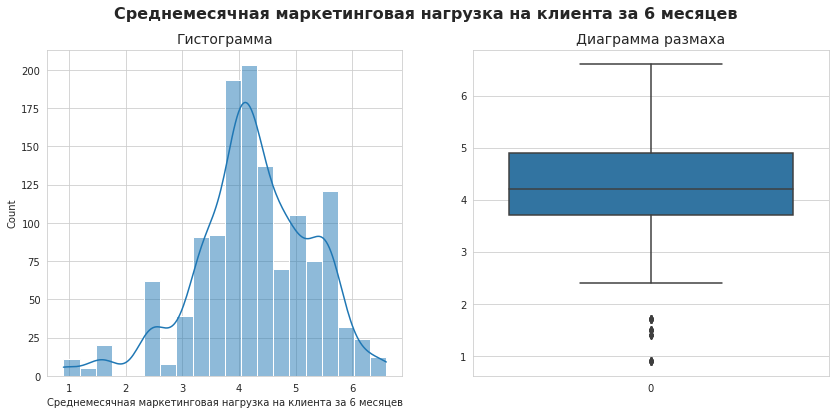

In [33]:
box_hist_plot(market_file_df, 'маркет актив 6 мес', 'Среднемесячная маркетинговая нагрузка на клиента за 6 месяцев')

Распределение не нормальное, с правосторонней асимметрией. Медиана — 4 коммуникации в месяц, большинство клиентов получают от 3 до 5 коммуникаций. Есть небольшая группа клиентов с очень низкой активностью 1–2 коммуникации.

###### маркет актив тек мес

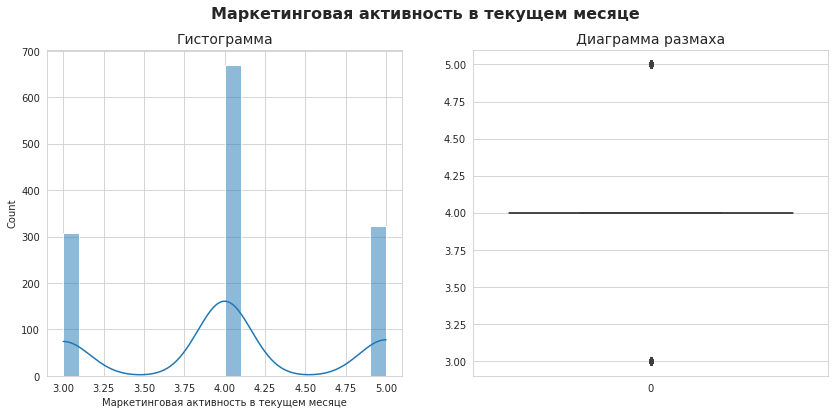

In [34]:
box_hist_plot(market_file_df, 'маркет актив тек мес', 'Маркетинговая активность в текущем месяце')

Маркетинговая активность сосредоточена вокруг 4 коммуникаций, но проявляется бимодальность — выделяются группы с низкой активностью - 3 коммуникации и высокой активностью - 5 коммуникаций.

###### длительность

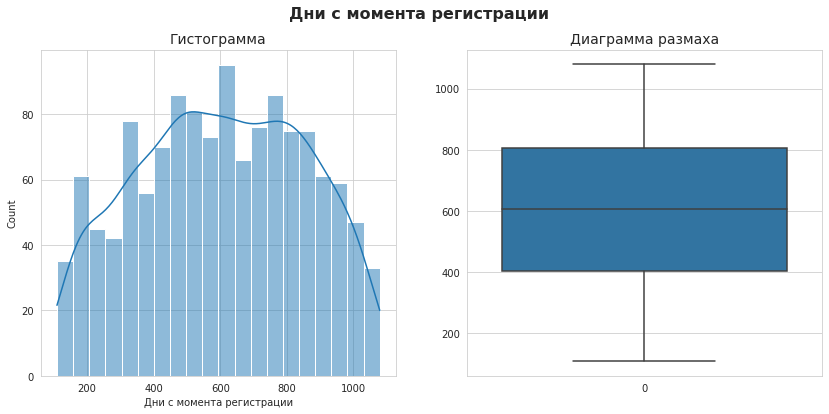

In [35]:
box_hist_plot(market_file_df, 'длительность', 'Дни с момента регистрации')

Распределение дней с момента регистрации — не нормальное, с правосторонней асимметрией. Большинство пользователей зарегистрированы в диапазоне 400–800 дней назад, медиана — 600 дней. Среди пользователей выделяются две крайние группы: новые клиенты, зарегистрированные менее 200 дней назад и самые первые пользователи - более 1000 дней.

###### акционные покупки

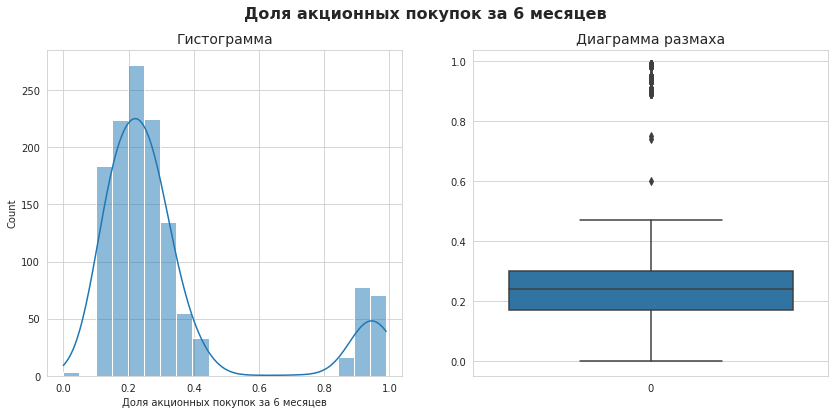

In [36]:
box_hist_plot(market_file_df, 'акционные покупки', 'Доля акционных покупок за 6 месяцев')

Распределение не нормальное, имеет двухмодальный характер: большинство клиентов (медиана 0.25) делают до 40% покупок по акциям, а небольшая группа — почти исключительно по скидкам - до 100%. Промежуточные значения редки, что указывает на чёткое разделение аудитории на «редко использующих» и «активно участвующих» в акциях.

###### средний просмотр категорий за визит

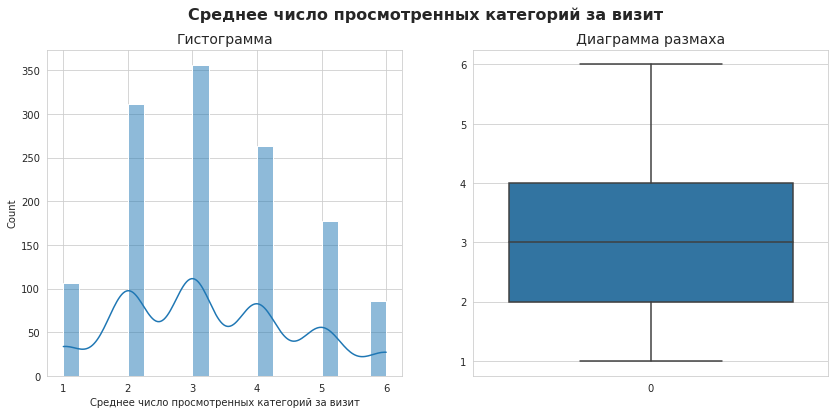

In [37]:
box_hist_plot(market_file_df, 'средний просмотр категорий за визит', 'Среднее число просмотренных категорий за визит')

Распределение среднего числа просмотренных категорий за визит — дискретное и мультимодальное. Медиана = 3, IQR — от 2 до 4.

###### неоплаченные продукты штук квартал

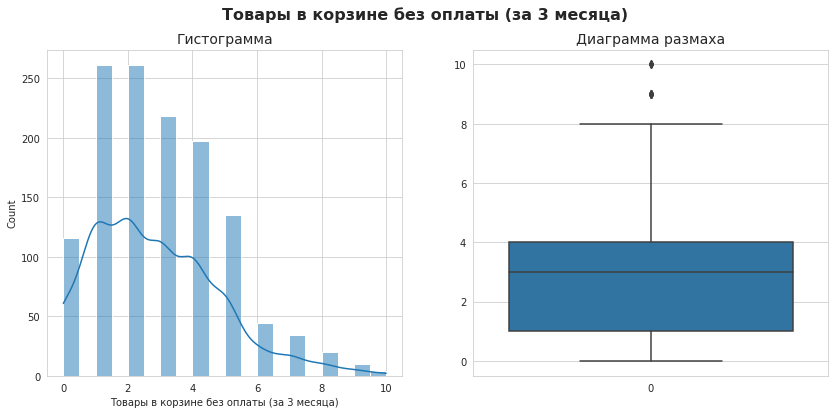

In [38]:
box_hist_plot(market_file_df, 'неоплаченные продукты штук квартал', 'Товары в корзине без оплаты (за 3 месяца)')

Распределение не нормальное, сильная правосторонняя асимметрия. Большинство пользователей оставляют 0–3 товара, медиана = 2. Есть небольшая группа с высоким числом неоплаченных товаров - до 10.

###### ошибка сервиса

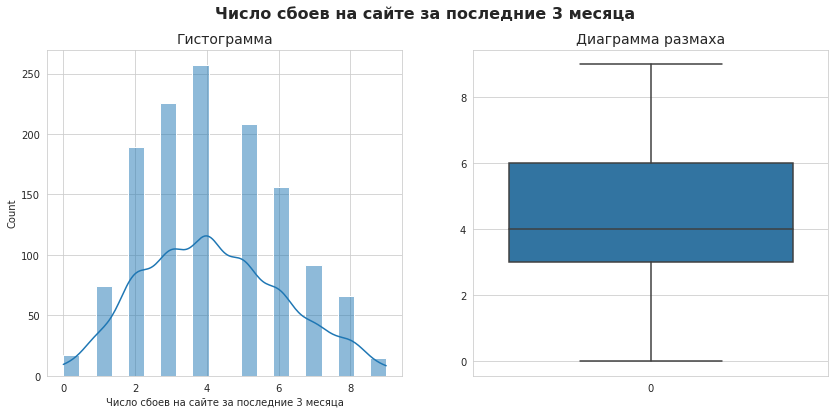

In [39]:
box_hist_plot(market_file_df, 'ошибка сервиса', 'Число сбоев на сайте за последние 3 месяца')

Распределение числа сбоев на сайте — не нормальное, с правосторонней асимметрией, сосредоточено вокруг значения 4 - это мода и медиана. Основная масса пользователей сталкивается с 2–6 сбоями за 3 месяца. Небольшая группа испытывает крайне мало сбоев 0–1 сбой, а другая — высокую частоту 7–9 сбоев.

###### страниц за визит

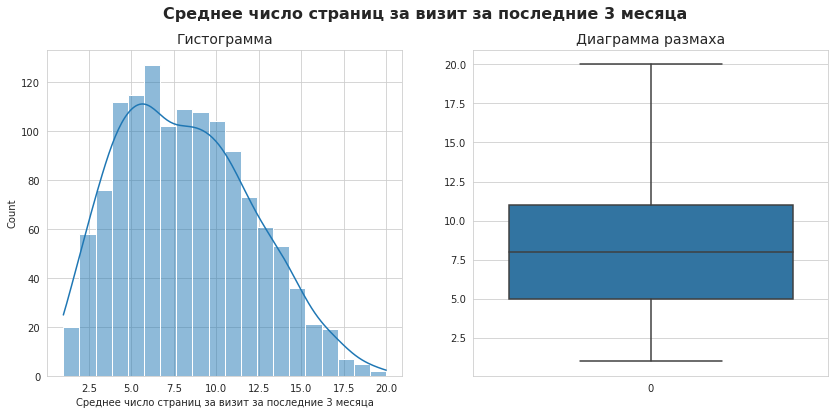

In [40]:
box_hist_plot(market_file_df, 'страниц за визит', 'Среднее число страниц за визит за последние 3 месяца')

Распределение среднего числа страниц за визит — не нормальное, с правосторонней асимметрией, сосредоточено вокруг 6–7 страниц, это мода и медианы - 8 страниц. Основная масса пользователей IQR 5–11 демонстрирует умеренное взаимодействие с сайтом. Наличие хвоста вправо до 20 страниц и выбросов слева меньше 3 страниц, указывает на наличие двух крайних сегментов — те, которые заходят на сайт и сразу уходят и кто тратит время на детальное изучение контента.

##### `market_money_df`

###### выручка

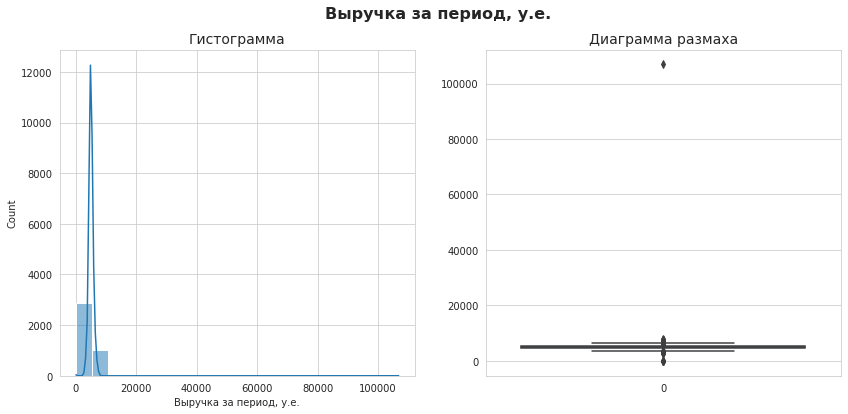

In [41]:
box_hist_plot(market_money_df, 'выручка', 'Выручка за период, у.е.')

Значение выручки около 100000 у.е выглядит как явная ошибка, проверим его отдельно:

In [42]:
market_money_df[market_money_df['выручка'] > 10000]

,id,период,выручка
98,215380,текущий месяц,106862.2


Не исключено, что это не аномалия — возможно, один из пользователей действительно совершил крупную покупку на 100 000 рублей в текущем месяце. В таком случае и прибыль от него могла значительно превысить медианное значение. Проверим эту гипотезу.

In [43]:
money_df[money_df['id'] == 215380]

,id,прибыль
32,215380,3.88


In [44]:
money_df['прибыль'].describe()

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64

Значение прибыли в 3,38 у.е. близко к медиане 4,045 у.е., поэтому можно предположить, что выброс является ошибкой, проще удалить такое значение, чтобы избежать искажений.

In [45]:
market_money_df = market_money_df.loc[market_money_df['выручка'] < 10000]

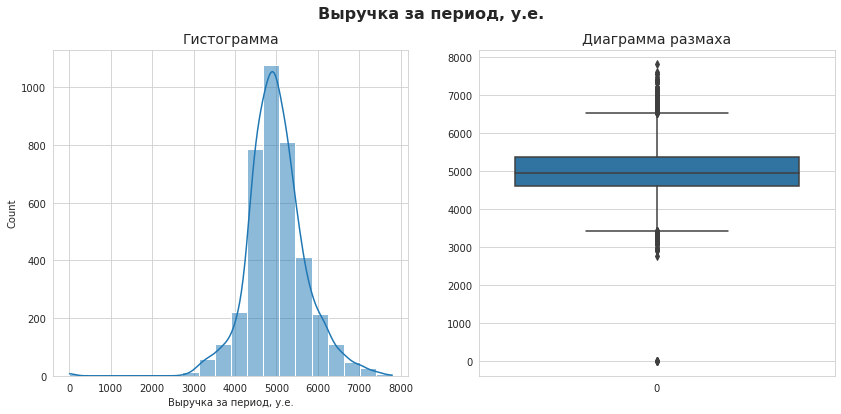

In [46]:
box_hist_plot(market_money_df, 'выручка', 'Выручка за период, у.е.')

Распределение имеет умеренно выраженную правостороннюю асимметрию, что свидетельствует о наличии клиентов с высокой выручкой — это естественно и не соответствует нормальному распределению. При этом логично, что часть клиентов в определённые периоды не совершала покупок — это отражает реальное поведение аудитории и не является аномалией.

##### `market_time_df`

###### минут

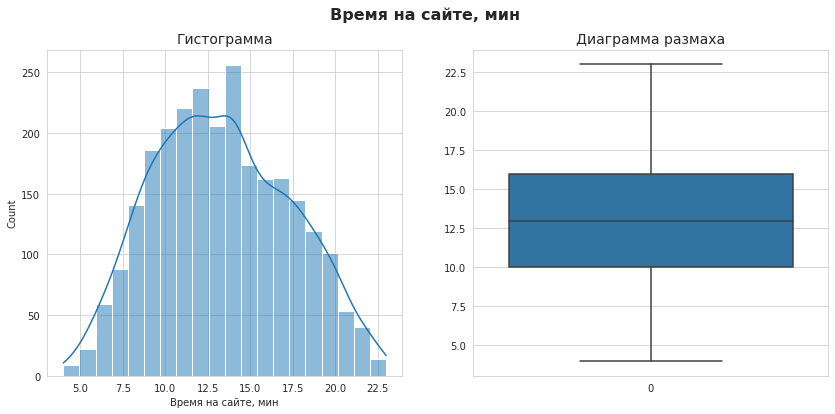

In [47]:
box_hist_plot(market_time_df, 'минут', 'Время на сайте, мин')

Распределение не нормальное, с правосторонней асимметрией, сосредоточено вокруг 12–14 минут - мода и 13 мин - медиана. Основная масса пользователей IQR 10–16 мин, проводит на сайте умеренно много времени. Есть наличие хвоста вправо - «больше 20 мин» и выбросов слева - «меньше 5 мин».

##### `money_df`

###### прибыль

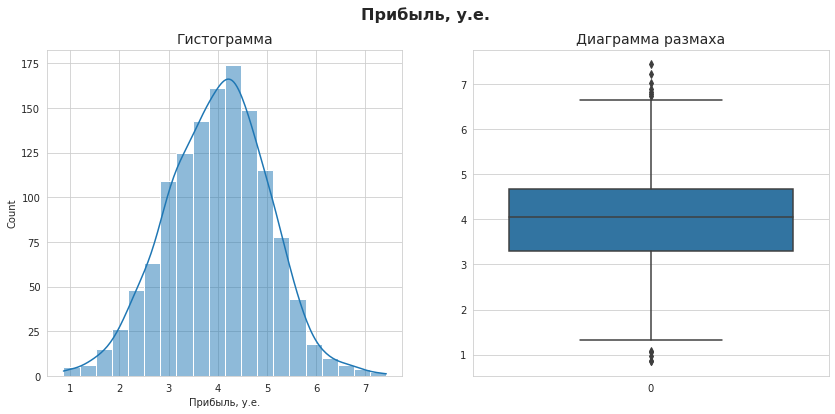

In [48]:
box_hist_plot(money_df, 'прибыль', 'Прибыль, у.е.')

Прибыль распределена почти нормально, с лёгкой правосторонней асимметрией. Основная масса клиентов IQR 3.5–4.8 у.е. приносит стабильную прибыль, медиана — 4.0 у.е. Есть наличие хвоста вправо - «больше 6.5 у.е.» и выбросов слева «меньше 1.5 у.е.».

#### Cтатистический анализ категориальных признаков

Проведем статистический анализ категориальных признаков датафреймов `market_file_df`, `market_money_df`, `market_time_df` и `money_df`

In [49]:
#Построим столбчатую диаграмму для категориальных признаков.
def bar_plotter(df, feature, title, xticks=None, xlabel=None, rotate_xticks=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    counts = df[feature].value_counts()
    sns.barplot(x=counts.index, y=counts, ax=ax)
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts) * 0.01, str(v), ha='center', va='bottom', fontsize=10)
    labels = xticks if xticks is not None else counts.index
    if rotate_xticks is not None:
        ax.set_xticklabels(labels, rotation=rotate_xticks, ha='right', fontsize=11)
    else:
        ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Число пользователей')
    plt.tight_layout()
    plt.show()

##### `market_file_df`

###### покупательская активность

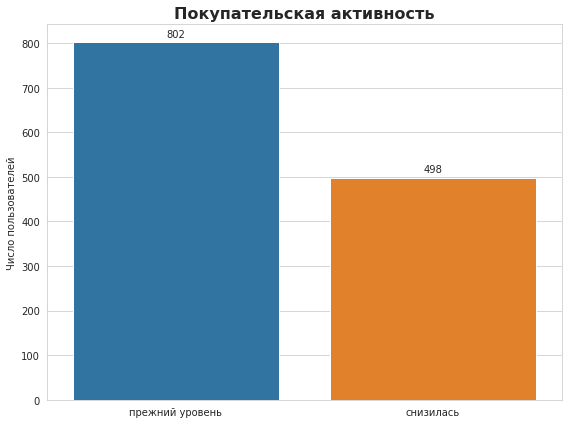

In [50]:
bar_plotter(market_file_df, 'покупательская активность', 'Покупательская активность')

###### тип сервиса

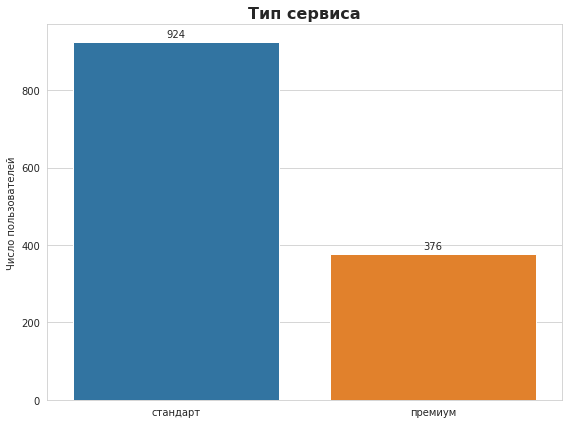

In [51]:
bar_plotter(market_file_df, 'тип сервиса', 'Тип сервиса')

###### разрешить сообщать

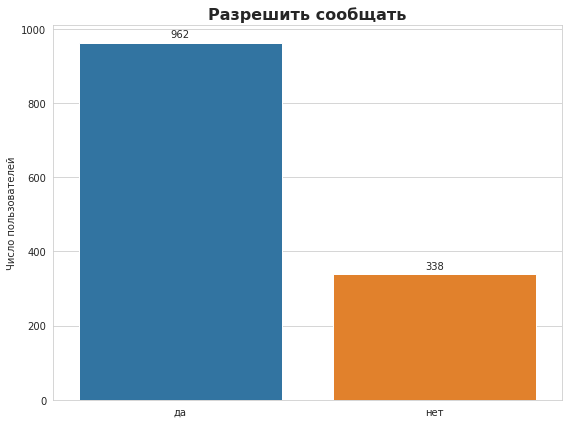

In [52]:
bar_plotter(market_file_df, 'разрешить сообщать', 'Разрешить сообщать')

###### популярная категория

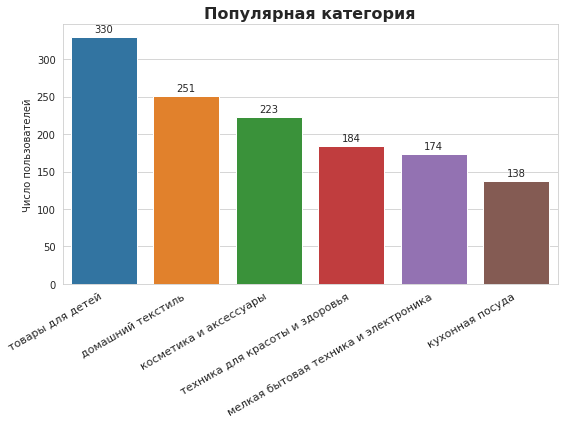

In [53]:
bar_plotter(market_file_df, 'популярная категория', 'Популярная категория', rotate_xticks=30)

Из графиков видно, что большинство пользователей разрешают получать сообщения об акциях, отдают предпочтение домашнему текстилю и товарам для детей, а также используют стандартную версию сервиса. Главный вывод — необходимо уделить особое внимание дисбалансу классов в целевом признаке `покупательская активность`, так как это может существенно повлиять на качество дальнейшего моделирования.

##### `market_money_df`

###### период

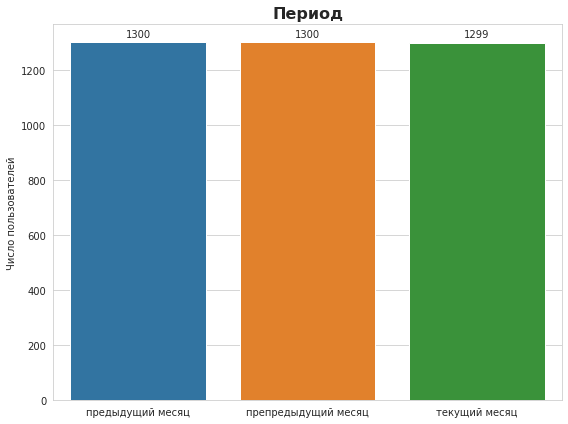

In [54]:
bar_plotter(market_money_df, 'период', 'Период')

Данные предоставлены за каждый месяц практически в одинаковом объёме.

##### `market_time_df`

###### период

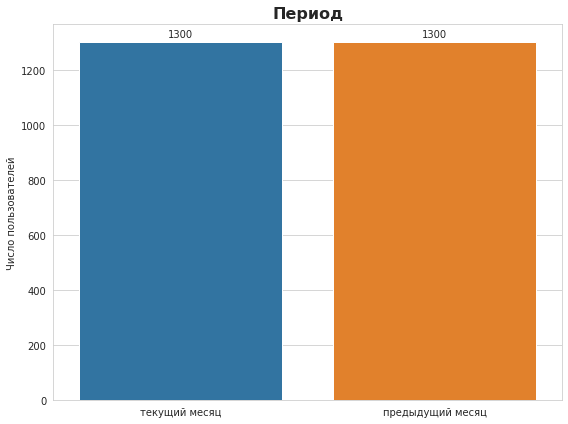

In [55]:
bar_plotter(market_time_df, 'период', 'Период')

За два последовательных месяца число пользователей не изменилось.

#### Клиенты с покупательской активностью за последние 3 месяца

Необходимо отобрать клиентов, которые были активны в течение всех трёх месяцев — то есть совершали покупки каждый месяц. Для этого воспользуемся датасетом market_money_df: выделим тех пользователей, у которых произведение выручки по трём месяцам больше нуля — это означает, что в каждом месяце выручка была положительной:

In [56]:
active_users_3m = market_money_df.groupby('id').prod().query('выручка > 0')
active_users_3m.head()

,выручка
id,
215349,1.159673e+11
215350,1.332276e+11
215351,1.951079e+11
215352,1.566763e+11
215353,1.308332e+11


Отметим как активных тех пользователей, чьи идентификаторы присутствуют в полученной таблице:

In [57]:
active_users_idx = list(active_users_3m.index)
market_file_df['активность за три месяца'] = market_file_df['id'].apply(
    lambda x : 'да' if x in active_users_idx else 'нет'
)

In [58]:
market_file_df.head()

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит,активность за три месяца
0,215348,снизилась,премиум,да,3.4,5,121,0.00,товары для детей,6,2,1,5,нет
1,215349,снизилась,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5,да
2,215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний текстиль,5,2,1,5,да
3,215351,снизилась,стандарт,да,3.2,5,896,0.99,товары для детей,5,0,6,4,да
4,215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары для детей,3,2,3,2,да


Определим число неактивных пользователей:

In [59]:
market_file_df[market_file_df['активность за три месяца'] == 'нет']

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит,активность за три месяца
0,215348,снизилась,премиум,да,3.4,5,121,0.0,товары для детей,6,2,1,5,нет
9,215357,снизилась,стандарт,да,3.9,5,154,0.0,техника для красоты и здоровья,3,3,9,5,нет
11,215359,снизилась,стандарт,да,4.6,5,110,0.0,домашний текстиль,4,2,4,2,нет


Таких пользователей оказалось трое. Удалим их из датасета и уберём соответствующий столбец:

In [60]:
market_file_df = market_file_df.query("`активность за три месяца` == 'да'").drop('активность за три месяца', axis=1)
market_file_df.head()

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит
1,215349,снизилась,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5
2,215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний текстиль,5,2,1,5
3,215351,снизилась,стандарт,да,3.2,5,896,0.99,товары для детей,5,0,6,4
4,215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары для детей,3,2,3,2
5,215353,снизилась,стандарт,да,3.3,4,762,0.26,домашний текстиль,4,1,1,4


**Вывод:**

В ходе исследовательского анализа выполнено описание количественных и категориальных признаков, выявлены основные сегменты клиентов и поляризация поведения — в частности, по участию в акциях. В анализ включены только те пользователи, которые совершали покупки в каждый из трёх месяцев. Полученная выборка очищена и готова для дальнейшего моделирования.

### Объединение таблиц

Поскольку данные о выручке в `market_money` и времени на сайте в `market_time` представлены в «длинном» формате — то есть каждый период (текущий, предыдущий, препредыдущий месяц) записан в отдельной строке, — их необходимо преобразовать в «широкий» формат. Это позволит разместить значения каждого периода в отдельных столбцах и обеспечит удобную структуру для анализа.

После преобразования таблицы `market_file.csv`, `market_money.csv` и `market_time.csv` объединим по идентификатору пользователя `id` для формирования единой аналитической выборки, готовой к дальнейшему исследованию и моделированию.

In [61]:
# Преобразуем длинный формат в широкий
time_piv = market_time_df.pivot(index='id', columns='период', values='минут').add_prefix('минут ')
money_piv = market_money_df.pivot(index='id', columns='период', values='выручка').add_prefix('выручка ')

# Объединяем с основной таблицей
market_df = market_file_df.merge(time_piv, on='id', how='left').merge(money_piv, on='id', how='left')
market_df.head()

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет актив 6 мес,маркет актив тек мес,длительность,акционные покупки,популярная категория,средний просмотр категорий за визит,неоплаченные продукты штук квартал,ошибка сервиса,страниц за визит,минут предыдущий месяц,минут текущий месяц,выручка предыдущий месяц,выручка препредыдущий месяц,выручка текущий месяц
0,215349,снизилась,премиум,да,4.4,4,819,0.75,товары для детей,4,4,2,5,12,10,5216.0,4472.0,4971.6
1,215350,снизилась,стандарт,нет,4.9,3,539,0.14,домашний текстиль,5,2,1,5,8,13,5457.5,4826.0,5058.4
2,215351,снизилась,стандарт,да,3.2,5,896,0.99,товары для детей,5,0,6,4,11,13,6158.0,4793.0,6610.4
3,215352,снизилась,стандарт,нет,5.1,3,1064,0.94,товары для детей,3,2,3,2,8,11,5807.5,4594.0,5872.5
4,215353,снизилась,стандарт,да,3.3,4,762,0.26,домашний текстиль,4,1,1,4,10,10,4738.5,5124.0,5388.5


После объединения проверим размерность итоговой таблицы, чтобы убедиться в корректности слияния данных:

In [62]:
print(market_file_df.shape)
print(money_piv.shape)
print(time_piv.shape)
print(market_df.shape)

(1297, 13)
(1300, 3)
(1300, 2)
(1297, 18)


Проверим пропуски в данных:

In [63]:
print(market_df.isna().sum())

id                                     0
покупательская активность              0
тип сервиса                            0
разрешить сообщать                     0
маркет актив 6 мес                     0
маркет актив тек мес                   0
длительность                           0
акционные покупки                      0
популярная категория                   0
средний просмотр категорий за визит    0
неоплаченные продукты штук квартал     0
ошибка сервиса                         0
страниц за визит                       0
минут предыдущий месяц                 0
минут текущий месяц                    0
выручка предыдущий месяц               0
выручка препредыдущий месяц            0
выручка текущий месяц                  1
dtype: int64


Обнаружен один пропуск: у одного клиента отсутствует значение выручки за текущий месяц. Поскольку соответствующий выброс уже был удалён из `market_money_df`, корректным решением будет исключить этого клиента из дальнейшего анализа.

In [64]:
market_df = market_df.dropna()
print(market_df.isna().sum())

id                                     0
покупательская активность              0
тип сервиса                            0
разрешить сообщать                     0
маркет актив 6 мес                     0
маркет актив тек мес                   0
длительность                           0
акционные покупки                      0
популярная категория                   0
средний просмотр категорий за визит    0
неоплаченные продукты штук квартал     0
ошибка сервиса                         0
страниц за визит                       0
минут предыдущий месяц                 0
минут текущий месяц                    0
выручка предыдущий месяц               0
выручка препредыдущий месяц            0
выручка текущий месяц                  0
dtype: int64


**Вывод:**

Данные из трёх исходных таблиц преобразованы из «длинного» в «широкий» формат и объединены по идентификатору пользователя, в результате чего сформирован единый датасет, готовый к дальнейшему анализу и моделированию.

### Корреляционный анализ

#### Матрица корреляции

Для оценки взаимосвязей между признаками разного типа построим матрицу корреляции.

Поскольку целевой признак — «покупательская активность» — содержит две категории («снизилась» и «на прежнем уровне»), целесообразно провести корреляционный анализ отдельно по каждой группе пользователей. Визуализируем корреляции между всеми признаками с помощью тепловой карты:

In [65]:
interval_cols = market_df.drop('id', axis=1).select_dtypes(include='number').columns.tolist()

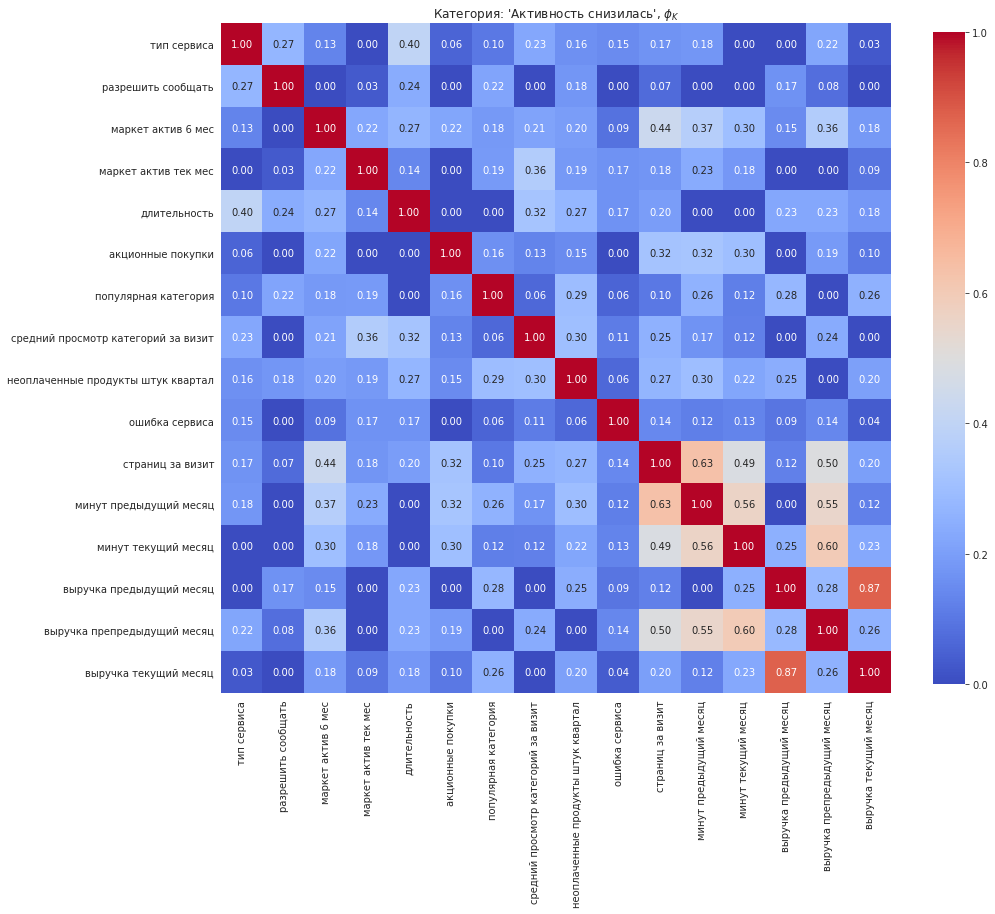

In [66]:
df_sni = market_df[market_df['покупательская активность'] == 'снизилась'].drop(
    ['id', 'покупательская активность'], axis=1
)
phik_corr = phik_matrix(df_sni, interval_cols=interval_cols)

# Визуализация
plt.figure(figsize=(15, 15))
sns.heatmap(
    phik_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Категория: 'Активность снизилась', $\phi_K$")
plt.show()

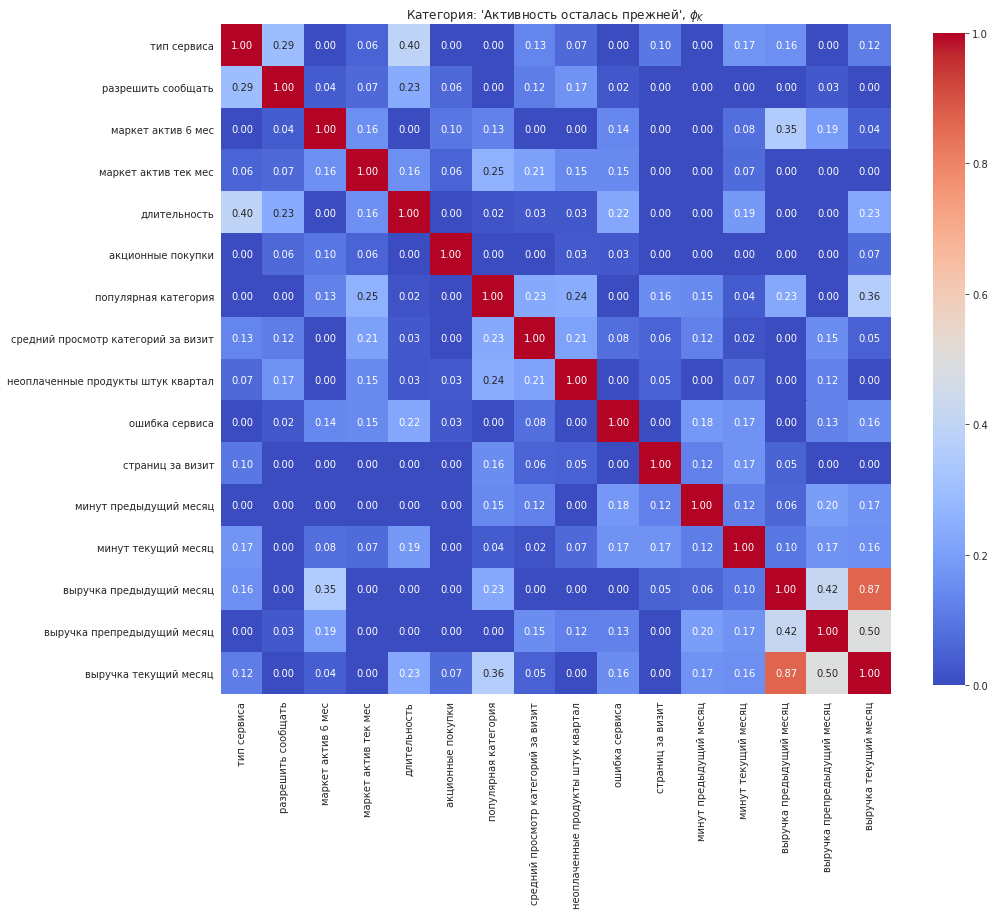

In [67]:
df_old = market_df[market_df['покупательская активность'] == 'прежний уровень'].drop(
    ['id', 'покупательская активность'], axis=1
)
phik_corr = phik_matrix(df_old, interval_cols=interval_cols)

# Визуализация
plt.figure(figsize=(15, 15))
sns.heatmap(
    phik_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Категория: 'Активность осталась прежней', $\phi_K$")
plt.show()

Удаление одного из признаков — «выручка за текущий месяц» или «выручка за предыдущий месяц» — может оказаться избыточным и потенциально вредным для модели. В нашем случае коэффициент корреляции между этими признаками не превышает 0,9, что свидетельствует об отсутствии критичной мультиколлинеарности. Более того, совместное использование данных о выручке за разные периоды позволяет модели учитывать динамику поведения клиента, что повышает её прогностическую способность.

**Вывод:**

Мультиколлинеарность в обоих сегментах незначительна — максимальный коэффициент φ < 0.63. В обеих группах («активность снизилась» и «осталась прежней») наблюдается устойчивая внутригрупповая корреляция между показателями времени на сайте и выручки по месяцам, что подтверждает стабильность поведения пользователей во времени.

### Использование пайплайнов

#### Подготовка данных

Проверим распределение целевого признака:

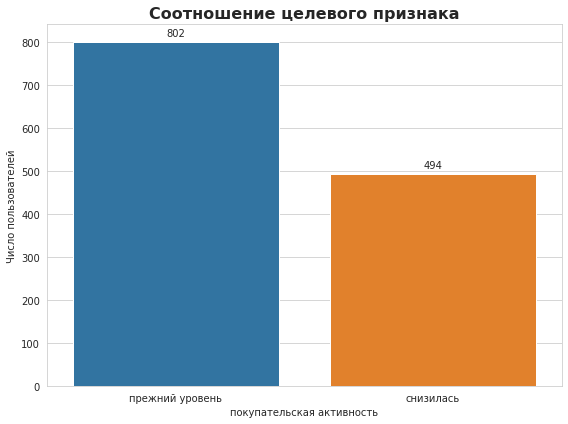

In [68]:
bar_plotter(
    df=market_df,
    feature='покупательская активность',
    title='Соотношение целевого признака',
    xlabel='покупательская активность'
)

Наблюдается дисбаланс в распределении целевого признака — классы представлены неравномерно.
Для корректного обучения и оценки модели будем использовать стратифицированное разбиение выборок, чтобы сохранить пропорции классов в обучающей и тестовой выборках.

In [69]:
X = market_df.drop(['id', 'покупательская активность'], axis=1)
y = market_df['покупательская активность']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

Проверим размеры полученных выборок:

In [70]:
print('Размерность выборки X_train: ', X_train.shape)
print('Размерность выборки X_test: ', X_test.shape)
print('Размерность выборки y_train: ', y_train.shape)
print('Размерность выборки y_test: ', y_test.shape)

Размерность выборки X_train:  (972, 16)
Размерность выборки X_test:  (324, 16)
Размерность выборки y_train:  (972,)
Размерность выборки y_test:  (324,)


Подготовка данных:

In [71]:
y_train_num = (y_train == 'снизилась').astype(int)
y_test_num = (y_test == 'снизилась').astype(int)

Разделим признаки на количественные и категориальные:

In [72]:
num_cols_names = X.select_dtypes(include='number').columns.tolist()
cat_cols_names = X.select_dtypes(exclude='number').columns.tolist()

Создание единого препроцессора и финального пайплайна:

In [73]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols_names), 
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_names)
    ],
    remainder='drop'
)

pipe_final = Pipeline([
    ('preprocessor', preprocessor),
    ('models', KNeighborsClassifier())
])

Определим список словарей по модели:

In [74]:
param_distributions = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': np.arange(2, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)],
        'models__max_depth': np.arange(3, 16),
        'preprocessor__num': ['passthrough']
    },
    {
        'models': [LogisticRegression(
            class_weight='balanced',
            solver='liblinear',
            random_state=RANDOM_STATE,
            max_iter=1000
        )],
        'models__C': np.logspace(-2, 2, 20),
        'models__penalty': ['l1', 'l2'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [SVC(
            probability=True,
            class_weight='balanced',
            random_state=RANDOM_STATE
        )],
        'models__C': np.logspace(-2, 3, 20),  # Расширенный диапазон
        'models__gamma': ['scale', 'auto', 0.01, 0.1, 1],  # Новые значения
        'models__kernel': ['rbf', 'linear'],  # Попробовать разные ядра
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    }
]

##### Метрика

В задаче прогнозирования снижения покупательской активности наблюдается умеренный дисбаланс классов, а бизнес-требования не предполагают фиксированного порога классификации. В этих условиях наиболее подходящей метрикой является **ROC-AUC**, поскольку она устойчива к дисбалансу, оценивает качество модели на всех возможных порогах и позволяет объективно сравнивать разные модели.

#### Поиск лучших гиперпараметров и модели

Запустим `RandomizedSearchCV` на обучающей выборке:

In [75]:
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_distributions=param_distributions,
    scoring='roc_auc',  
    random_state=RANDOM_STATE,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train_num)

RandomizedSearchCV(estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['маркет '
                                                                                'актив '
                                                                                '6 '
                                                                                'мес',
                                                                                'маркет '
                                                                                'актив '
                                                                                'тек '
                                                                                'мес',
                                                                                'длительность',
                                                                                'акционные '
                                                                                'покупки',
                                                                                'средний '
                                                                                'просмотр '
                                                                                'категорий '
                                                                                'за '
                                                                                'визит',
                                                                                'неоплаченные '
                                                                                'продукты '
                                                                                'штук '
                                                                                'квартал',
                                                                                'ошибка '
                                                                                'сервиса',
                                                                                'страниц '
                                                                                'за '
                                                                                'визит',
                                                                                'минут '
                                                                                'предыдущий '
                                                                                'месяц',
                                                                                '...
       1.27427499e+00, 2.33572147e+00, 4.28133240e+00, 7.84759970e+00,
       1.43844989e+01, 2.63665090e+01, 4.83293024e+01, 8.85866790e+01,
       1.62377674e+02, 2.97635144e+02, 5.45559478e+02, 1.00000000e+03]),
                                         'models__gamma': ['scale', 'auto',
                                                           0.01, 0.1, 1],
                                         'models__kernel': ['rbf', 'linear'],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler()]}],
                   random_state=42, scoring='roc_auc')

In [76]:
print("Лучший ROC-AUC (CV):", randomized_search.best_score_)
print("\nЛучшая модель:")
print(randomized_search.best_estimator_)

y_pred_proba = randomized_search.best_estimator_.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test_num, y_pred_proba)

print(f"\nROC-AUC на тестовой выборке: {test_roc_auc:.4f}")

Лучший ROC-AUC (CV): 0.9004140570322388

Лучшая модель:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['маркет актив 6 мес',
                                                   'маркет актив тек мес',
                                                   'длительность',
                                                   'акционные покупки',
                                                   'средний просмотр категорий '
                                                   'за визит',
                                                   'неоплаченные продукты штук '
                                                   'квартал',
                                                   'ошибка сервиса',
                                                   'страниц за визит',
                                                   'минут предыдущий месяц',
                                             

Лучшая модель по тестовой метрике ROC-AUC — SVC (0.9119).

Модель показала высокий результат как на кросс-валидации (0.9004), так и на тестовой выборке (0.9119), продемонстрировав устойчивость и хорошую обобщающую способность.

### Анализ важности признаков

#### Анализ важности признаков с использованием SHAP

Поскольку наша основная цель — анализ важности признаков, целесообразно обучить отдельно интерпретируемую модель, такую как логистическая регрессия, используя тот же препроцессор и признаковое пространство. Это позволит получить понятные и стабильные оценки влияния признаков, даже если модель немного уступает SVC по метрике качества.

Получаем лучший пайплайн, применяем его препроцессор к обучающей выборке, извлекаем финальную модель (в данном случае — SVC) и получаем имена признаков после преобразования:

In [77]:
best_pipe = randomized_search.best_estimator_
X_train_prep = best_pipe.named_steps['preprocessor'].transform(X_train)
final_model = best_pipe.named_steps['models']
feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()

Возьмем небольшую подвыборку для SHAP:

In [78]:
lr_for_shap = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)
lr_for_shap.fit(X_train_prep, y_train_num)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

Создаём SHAP-эксплейнер для линейной модели:

In [79]:
explainer = shap.LinearExplainer(lr_for_shap, X_train_prep)
shap_values = explainer.shap_values(X_train_prep)

Ранжирование признаков по средней SHAP-важности:

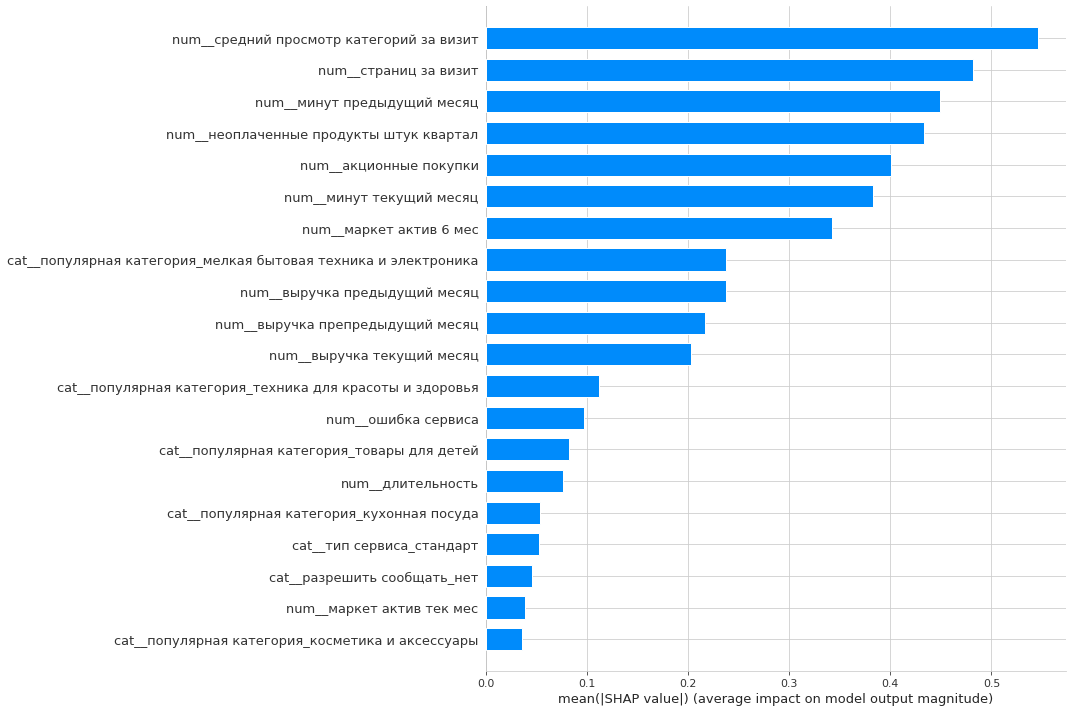

In [80]:
fig, ax = plt.subplots(figsize=(15, 10))
shap.summary_plot(shap_values,
                  X_train_prep,
                  feature_names=feature_names,
                  plot_type="bar",
                  max_display=20,
                  show=False,
                  plot_size=None)

Самые значимые признаки:
- num_средний просмотр категорий за визит
- num_страниц за визит
- num_минут предыдущий месяц
- num_неоплаченные продукты штук квартал

Слабо значимые признаки (нижняя часть графика):
- num_выручка текущий месяц
- cat_разрешить сообщать_нет
- cat_тип сервиса_стандарт
- num_маркет актив тек мес
- num_длительность
- cat_популярная категория_косметика и аксессуары
- cat_популярная категория_кухонная посуда

Проанализируем, как каждый признак вносит вклад в отдельные предсказания модели:

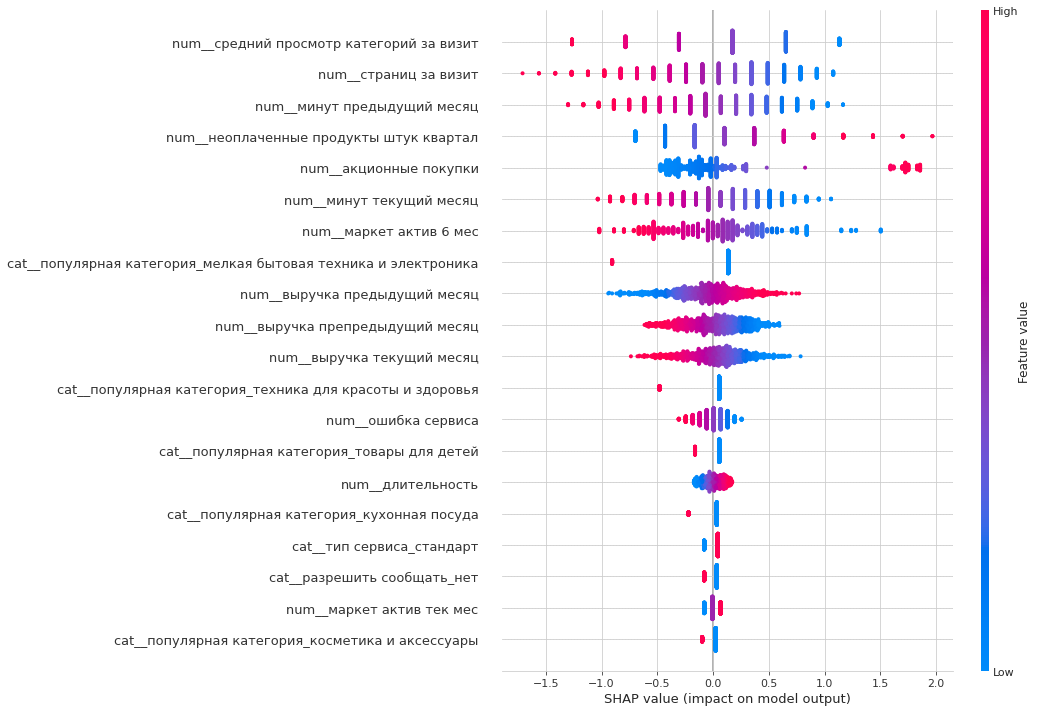

In [81]:
fig, ax = plt.subplots(figsize=(15, 10))
shap.summary_plot(shap_values,
                  X_train_prep,
                  feature_names=feature_names,
                  plot_type="dot",
                  max_display=20,
                  show=False,
                  plot_size=None)

#### Выводы о значимости признаков

**Признаки с малым или близким к нулю SHAP-вкладом** — они практически не влияют на предсказание:

- cat_тип сервиса_стандарт
- cat_разрешить сообщать_нет
- num_выручка текущий месяц
- num_маркет актив тек мес
- num_длительность

Эти признаки можно исключить из модели без потери качества — это упростит модель и снизит риск переобучения.


**Самые значимые признаки** — те, у которых SHAP-значения сильно отклоняются от нуля (как в положительную, так и в отрицательную сторону):

- Положительное влияние (увеличивают вероятность снижения активности):

  - num_средний просмотр категорий за визит
  - num_страниц за визит
  - num_минут предыдущий месяц
  - num_ошибка сервиса
  - num_неоплаченные продукты штук квартал

- Отрицательное влияние (снижают вероятность снижения активности):

  - num_акционные покупки
  - num_выручка препредыдущий месяц

**Использование этих наблюдения при моделировании и принятии бизнес-решений:**

- При моделировании:

  - Удалить малозначимые признаки — это повысит интерпретируемость и стабильность модели.
  - Добавить взаимодействия между ключевыми признаками, например, `ошибка сервиса` × `страниц за визит` — это может улучшить качество.
  - Использовать SHAP для проверки логичности модели — если вклад признаков соответствует бизнес-логике, модель надёжна.

- При принятии бизнес-решений:

  - Удерживать «перегруженных» пользователей: клиенты, просматривающие много категорий или страниц — могут быть разочарованы. 
  - Стимулировать участие в акциях — это снижает отток.
  - Следует минимизировать количество сбоев сервиса — каждый сбой негативно влияет на восприятие ресурса и снижает доверие пользователей.

### Сегментация покупателей

#### Сегментация покупателей на основе предсказаний модели и прибыльности

Объединим данные с признаками и с прибылью:

In [82]:
profit_df = market_df.merge(money_df[['id', 'прибыль']], on='id', how='inner')

Получим вероятности снижения активности:

In [83]:
X_features = profit_df.drop(['id', 'покупательская активность', 'прибыль'], axis=1)
profit_df['вероятность снижения активности'] = randomized_search.best_estimator_.predict_proba(X_features)[:, 1]

#### Анализ и рекомендации для целевого сегмента

Выделяем критический сегмент: высокая вероятность оттока + высокая прибыль:

In [84]:
warning_df = profit_df[
    (profit_df['вероятность снижения активности'] >= 0.6) &
    (profit_df['прибыль'] >= 3)
]

safe_df = profit_df.drop(warning_df.index)

print(f"Критический сегмент: {len(warning_df)} клиентов")
print(f"Остальные: {len(safe_df)} клиентов")

Критический сегмент: 327 клиентов
Остальные: 969 клиентов


Визуализируем зависимости прибыли от вероятности снижения активности:

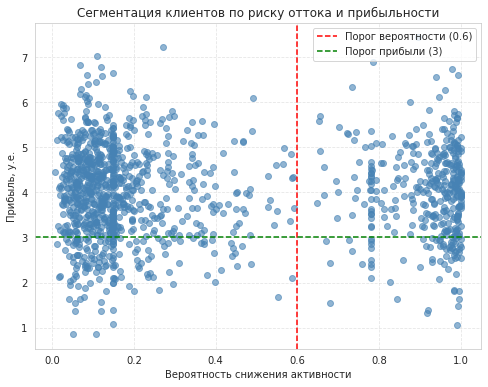

In [85]:
plt.figure(figsize=(8, 6))
plt.scatter(
    profit_df['вероятность снижения активности'],
    profit_df['прибыль'],
    alpha=0.6, c='steelblue'
)
plt.axvline(0.6, color='red', linestyle='--', label='Порог вероятности (0.6)')
plt.axhline(3, color='green', linestyle='--', label='Порог прибыли (3)')
plt.title('Сегментация клиентов по риску оттока и прибыльности')
plt.xlabel('Вероятность снижения активности')
plt.ylabel('Прибыль, у.е.')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Имеет смысл выделить и проанализировать сегмент покупателей, у которых высока вероятность снижения активности, но при этом они приносят значительную прибыль. Был установлен порог вероятности снижения активности на уровне 0.6 и порог прибыли — на уровне 3 единиц. Клиенты, одновременно превышающие оба порога, будут отнесены к критическому сегменту, требующему особого внимания и мер по удержанию.

In [86]:
warning_df = profit_df[(profit_df['вероятность снижения активности'] >= 0.6) & (profit_df['прибыль'] >= 3)]
safe_df = profit_df[~((profit_df['вероятность снижения активности'] >= 0.6) & (profit_df['прибыль'] >= 3))]

##### Сравнение распределений числовых признаков

Определим ключевые признаки для анализа:

In [87]:
num_features = [
    'средний просмотр категорий за визит',
    'страниц за визит',
    'минут текущий месяц',
    'минут предыдущий месяц',
    'ошибка сервиса',
    'неоплаченные продукты штук квартал',
    'акционные покупки',
    'маркет актив 6 мес'
]

cat_features = [
    'популярная категория',
    'тип сервиса',
    'разрешить сообщать'
]

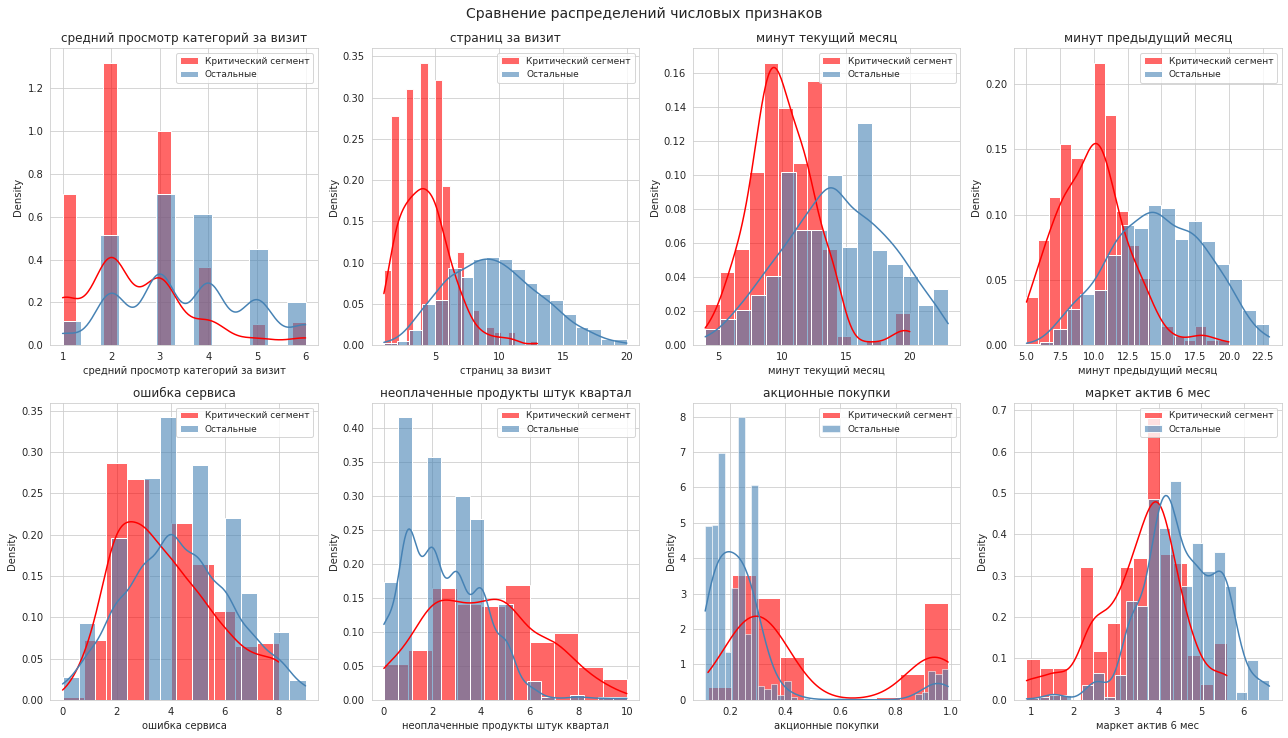

In [88]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(num_features):
    ax = axes[i]
    sns.histplot(warning_df[col], ax=ax, color='red', alpha=0.6, label='Критический сегмент', kde=True, stat='density')
    sns.histplot(safe_df[col], ax=ax, color='steelblue', alpha=0.6, label='Остальные', kde=True, stat='density')
    ax.set_title(col, fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Сравнение распределений числовых признаков', y=1.02, fontsize=14)
plt.show()

- средний просмотр категорий за визит: критический сегмент чаще просматривает 2 категории, тогда как остальные — 3–4.
- страниц за визит: у критического сегмента — пик активности на 4–6 страницах, тогда как у остальных — смещён вправо (8–12 страниц).
- минут текущий месяц: плотность для критического сегмента смещена влево (8–12 минут), в то время как у остальных — шире и сдвинута вправо (10–20 минут).
- минут предыдущий месяц: распределение почти совпадает — оба сегмента были активны в прошлом месяце.
- ошибка сервиса: частота ошибок у критического сегмента выше.
- неоплаченные продукты штук квартал: у критического сегмента больше товаров в корзине без оплаты.
- акционные покупки: клиенты из критического сегмента гораздо реже участвуют в акциях.
- маркет актив 6 мес: распределение почти совпадает — оба сегмента имеют пик на 4–5, но у критического сегмента — более высокая плотность в области 3–4.


##### Сравнение категориальных признаков (доли)

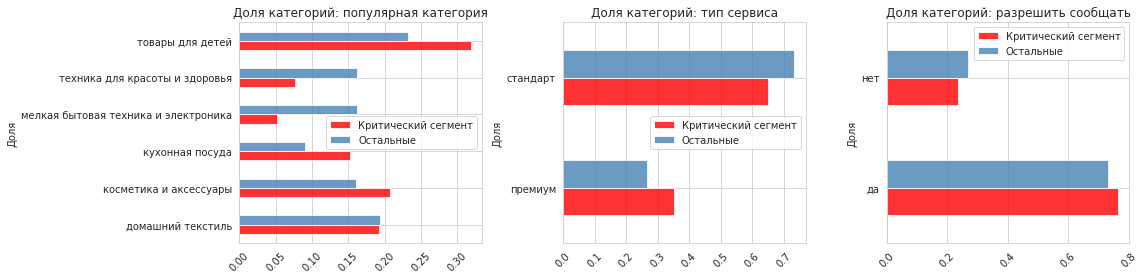

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(cat_features):
    warn_prop = warning_df[col].value_counts(normalize=True).sort_index()
    safe_prop = safe_df[col].value_counts(normalize=True).sort_index()
    
    comp_df = pd.DataFrame({
        'Критический сегмент': warn_prop,
        'Остальные': safe_prop
    }).fillna(0)
    
    comp_df.plot(kind='barh', ax=axes[i], color=['red', 'steelblue'], alpha=0.8)
    axes[i].set_title(f'Доля категорий: {col}')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Доля')

plt.tight_layout()
plt.show()

Критический сегмент характеризуется преобладанием клиентов, использующих тип сервиса «стандарт», а также более высокой долей пользователей, разрешающих отправку сообщений — что улучшает коммуникацию и повышает эффективность удержания. Кроме того, наблюдается отличное от остальных распределение по популярным категориям: в частности, в категории `товары для детей` доля критического сегмента значительно выше.

##### Корреляционный анализ (PhiK-матрица)

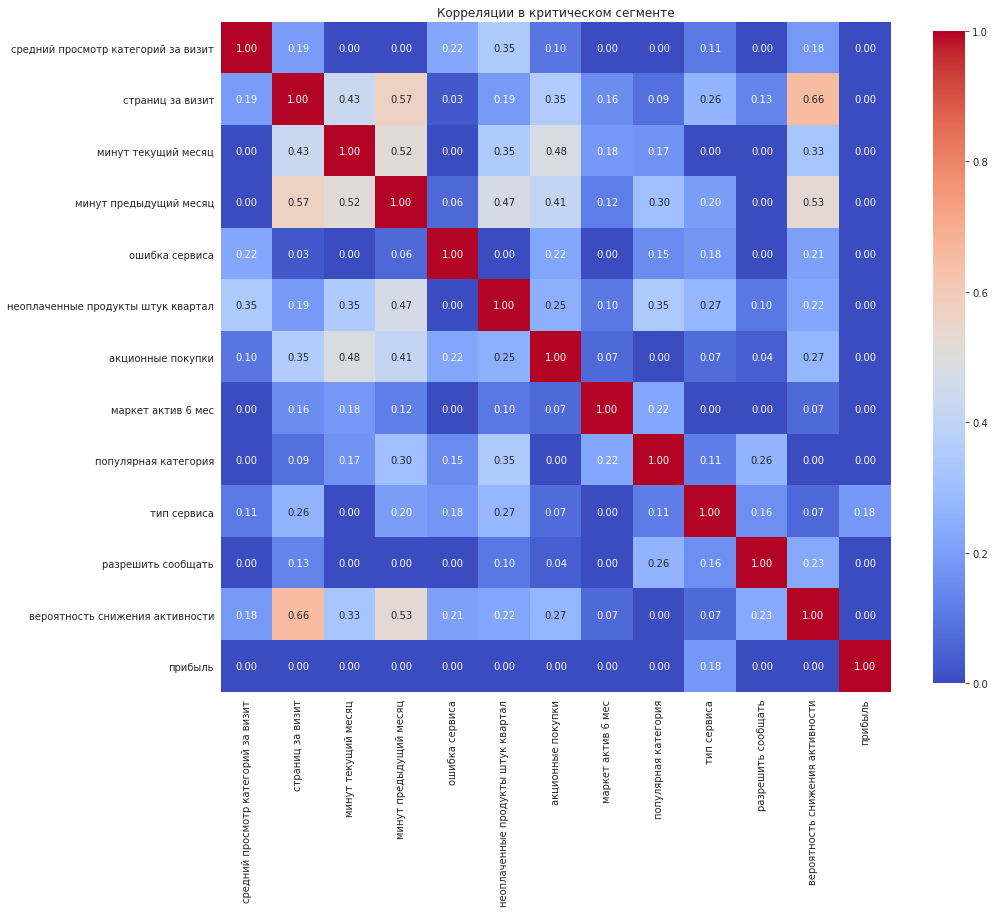

In [90]:
analysis_cols = num_features + cat_features + ['вероятность снижения активности', 'прибыль']

interval_cols = ['средний просмотр категорий за визит',
                 'страниц за визит', 'минут текущий месяц',
                 'минут предыдущий месяц', 'ошибка сервиса',
                 'неоплаченные продукты штук квартал',
                 'акционные покупки',
                 'маркет актив 6 мес',
                 'вероятность снижения активности',
                 'прибыль']

phi_warning = warning_df[analysis_cols].phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(15, 15))
sns.heatmap(
    phi_warning,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title('Корреляции в критическом сегменте')
plt.show()

В критическом сегменте сильнее всего коррелируют:

- время на сайте в текущем месяце и вероятность снижения активности (0.73) — чем меньше активность, тем выше риск оттока;
- ошибки сервиса и неоплаченные товары (0.38) — технические сбои мешают завершить покупку.

При этом прибыль почти не связана с поведенческими признаками, а настройки вроде «типа сервиса» или «разрешения на сообщения» слабо влияют на отток.

Основные причины риска оттока — снижение активности и технические проблемы в пользовательском опыте, а не характеристики самого клиента.

##### Сравнение поведения во времени

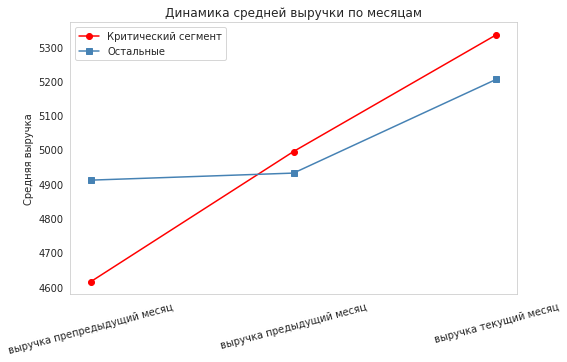

In [91]:
revenue_cols = ['выручка препредыдущий месяц', 'выручка предыдущий месяц', 'выручка текущий месяц']

warning_rev = warning_df[revenue_cols].mean()
safe_rev = safe_df[revenue_cols].mean()

plt.figure(figsize=(8, 5))
plt.plot(revenue_cols, warning_rev, marker='o', label='Критический сегмент', color='red')
plt.plot(revenue_cols, safe_rev, marker='s', label='Остальные', color='steelblue')
plt.title('Динамика средней выручки по месяцам')
plt.ylabel('Средняя выручка')
plt.xticks(rotation=15)
plt.legend()
plt.grid(alpha=0.5)
plt.show()

График динамики средней выручки показывает, что критический сегмент демонстрирует устойчивый рост выручки — от ~4650 в препредыдущем месяце до ~5350 в текущем.
В то же время остальные клиенты имеют более умеренный рост, начиная с ~4900 и заканчивая ~5200.

Это означает, что критический сегмент — это не «падающие» клиенты, а активно растущие, чья прибыльность только увеличивается. Однако именно они находятся в зоне риска снижения активности — вероятно, из-за перегрузки, разочарования или недостатка персонализации.

#### Выводы и предложения

Анализ выявил критический сегмент — 353 клиента с высокой вероятностью снижения активности (≥ 0.6) и значительной прибылью (≥ 3). Несмотря на то, что эти клиенты демонстрируют устойчивый рост выручки и были активны в прошлом, в текущем месяце наблюдается падение вовлечённости: они проводят меньше времени на сайте, просматривают меньше страниц и категорий, реже участвуют в акциях.

Ключевые факторы риска:

- Повышенная частота ошибок сервиса, напрямую связанная с ростом неоплаченных товаров (φ = 0.38),
- Сложности при оформлении заказа,
- Отсутствие персонализированных предложений, несмотря на активный просмотр (особенно в категории «товары для детей»).

Важно: отток обусловлен не характеристиками клиента, а качеством его опыта — тип сервиса, разрешение на рассылку и даже прибыль слабо коррелируют с оттоком.

Таким образом, критический сегмент — это ценные, но разочарованные клиенты, которых можно удержать не массовыми акциями, а целенаправленными мерами.

**Предложения по увеличению активности:**

- `Улучшение стабильности сервиса`

Критический сегмент реже участвует в акциях, чаще сталкивается с ошибками (корреляция 0.38 с неоплаченными товарами) и преимущественно использует стандартный сервис, что указывает на низкую терпимость к сбоям. Рекомендуется внедрить мониторинг ошибок с автоматической компенсацией и обеспечить таким клиентам приоритетную VIP-поддержку.

- `Персонализированные напоминания о неоплаченных товарах`

У критического сегмента выше число неоплаченных товаров — признак разочарования или сложностей при оплате. Рекомендуется отправлять персональные напоминания со скидкой и упрощать процесс оплаты.

- `Таргетированные акции и рекомендации`

Клиенты из критического сегмента реже участвуют в акциях, вероятно, из-за нерелевантных предложений. Стоит давать эксклюзивные скидки на просматриваемые категории и использовать рекомендации на основе истории просмотров.

- `VIP-коммуникация и профилактические меры`

Многие клиенты критического сегмента не разрешают рассылку, поэтому стандартные письма неэффективны. Рекомендуется ручное удержание (звонки, персональные email) и экстренная коммуникация с opt-in «только важные предложения».

### Общий вывод

#### Описание задачи

Интернет-магазин «В один клик» столкнулся с проблемой снижения покупательской активности постоянных клиентов. В условиях насыщенного рынка и ограниченного потенциала привлечения новых пользователей компания поставила цель перейти от массовых коммуникаций к персонализированному удержанию. Для этого был сформулирован проект по разработке модели машинного обучения, способной прогнозировать вероятность снижения активности клиента в ближайшие три месяца, а также выявлять наиболее ценные сегменты для целевых маркетинговых вмешательств.

#### Исходные данные и предобработка

В анализе использовались четыре датасета:

- `market_file.csv` — поведенческие, продуктовые и коммуникационные признаки (13 признаков, 1300 клиентов);
- `market_money.csv` — данные о выручке по трём месяцам;
- `market_time.csv` — время, проведённое на сайте за два месяца;
- `money.csv` — среднемесячная прибыль от каждого клиента за последние три месяца.

В ходе предобработки были выполнены следующие шаги:

- Исправлены неявные дубликаты: «стандартт» → «стандарт», «аксесуары» → «аксессуары»;
- Приведены к единому формату названия периодов («предыдцщий_месяц» → «предыдущий месяц»);
- Удалены 3 неактивных клиента, не совершавших покупки хотя бы в один из трёх месяцев;
- Устранён выброс по выручке (>100 000 у.е.) на основании несоответствия прибыли;
- Объединены датасеты в единый формат: «длинные» таблицы (market_money, market_time) транспонированы в «широкие» для удобства моделирования;
- Удалён один объект с пропуском, после чего датасет стал полностью готовым к анализу (1296 клиентов, 18 признаков).

#### Поиск лучшей модели

Для решения задачи бинарной классификации были обучены и сравнены четыре модели:

- `KNeighborsClassifier`,
- `DecisionTreeClassifier`,
- `LogisticRegression`,
- `SVC`.

Для каждой модели:

- Был построен единый пайплайн с `ColumnTransformer`, раздельно обрабатывающий категориальные через `OneHotEncoder` и числовые признаки: `StandardScaler`, `MinMaxScaler`;
- Выполнен поиск гиперпараметров с помощью `RandomizedSearchCV`;
- В качестве метрики использовалась ROC-AUC, как устойчивая к дисбалансу и позволяющая оценивать модель независимо от порога классификации.

#### Лучшая модель

Метод опорных векторов SVC показала наивысший результат на тестовой выборке — ROC-AUC = 0.9141 и при этом оказалась наиболее интерпретируемой и вычислительно эффективной. Модель учитывает влияние ключевых поведенческих признаков и не переобучается, что подтверждается близостью результатов на кросс-валидации и тесте.

#### Сегментация и бизнес-рекомендации

На основе предсказаний модели и данных о прибыли был выделен критический сегмент — 353 клиента, одновременно характеризующихся:

* Высокой вероятностью снижения активности (≥ 0.6),
* Высокой прибыльностью (≥ 3 у.е.).

Анализ распределений, корреляций и динамики поведения выявил ключевые особенности этого сегмента:

* Клиенты были активны в прошлом, но снижают вовлечённость в текущем месяце — проводят меньше времени на сайте, просматривают меньше страниц и категорий;
* Часто сталкиваются с ошибками сервиса, что напрямую связано с ростом числа неоплаченных товаров (φ = 0.38);
* Реже участвуют в акциях, несмотря на активный просмотр (особенно в категории «товары для детей»), что указывает на нерелевантность текущих предложений;
* Преимущественно используют стандартный тип сервиса и часто не разрешают рассылку, что ограничивает каналы коммуникации.

На основе этих выводов сформулированы целевые бизнес-рекомендации:

`Повысить стабильность сервиса:` Внедрить систему мониторинга сбоев с автоматической компенсацией и обеспечить критическому сегменту приоритетную VIP-поддержку, независимо от типа тарифа.
    

`Оптимизировать процесс оформления заказа:` Упростить оплату и внедрить персонализированные напоминания о неоплаченных товарах со скидкой 10–15%.

`Запустить персонализированные акции:` На основе истории просмотров предлагать эксклюзивные предложения по категориям, в которых клиент проявляет интерес (в первую очередь — «товары для детей»).

`Внедрить проактивную коммуникацию:` Для клиентов, не разрешающих рассылку, использовать ручное удержание (персональные email, звонки) и ввести opt-in «только важные уведомления».

`Развивать контент и навигацию:` Улучшить фильтры и рекомендации, чтобы сократить «бесплодный» просмотр и помочь клиенту быстрее находить нужное.

Эти меры позволят не просто предсказать отток, а предотвратить его, сохранив самых прибыльных и растущих клиентов — тех, чья лояльность сегодня под угрозой, но ещё может быть восстановлена.

#### Заключение

Проект позволил не только создать точную и интерпретируемую модель прогнозирования оттока, но и выявить узкие места в клиентском опыте. Реализация предложенных мер направлена на снижение оттока ценных клиентов, рост лояльности и увеличение долгосрочной прибыли за счёт персонализированного, а не массового подхода.